# Relatório Preliminar – Preço de Vendas de Imóveis da Terracap em Licitação Pública

### Grupo:
* Gustavo Salvador Ferraz Ferreira
* Shenia Rocha Ladeira
* Aliendres Souto Souza 
### Disciplina: Introdução ao Machine Learning 
* Prof. Dra. Roberta Moreira Wichmann
* 1º Bimestre de 2026


## 1. Descrição da Base de Dados
* A base de dados utilizada, foi obtida recuperando dados públicos de vendas de imóveis da Terracap em Licitações Públicas no período de 2020 a 2026.
* Foram extraídas todas as vendas de Editais de Licitação, para itens (imóveis) do tipo venda (à Vista/a prazo), pois a Terracap também publica Editais que possuem imóveis comercializados através de concessão/aluguel, no período de 2020 a 2026. Adicionamos o campo "quantidade de propostas" recebidas por cada imóvel, que fica em outra banco de dados, e também adicionamos o campo "situação do imóvel", referente a última vistoria realizada, que identifica a condição do imóvel (ocupado, obstruído, cercado, vago, etc), e que faz parte de outro banco de dados.

* As informações de imóveis vendidos, características dos imóveis, como destinação, tamanho da área, valor de avaliação, valor da venda, situação relatada pela vistoria, quantidade de propostas recebidas, são dados públicos e constam nas páginas de cada Edital de Venda específico, sendo divulgado publicamente também, o relatório de homologação de vencedores, no site da Terracap (https://www.terracap.df.gov.br)

* Os dados são relevantes, porque permitem analisar as vendas da Terracap ao longo do tempo, com perspectivas diferentes como: regiões administrativas do DF,  evolução de vendas por ano, pelas características do imóvel (tamanho, destinação, situação da vistoria), bem como verificar avaliar o valor do ágio absoluto do  imóvel (valor da venda - valor da avaliação), e também o ágio percentual.

* As variáveis derivadas de ágio absoluto e ágio percentual **NÃO** serão utilizadas como preditoras no treinamento do modelo, pois são calculadas a partir do valor de venda, o que configuraria vazamento de dados e comprometeria a validade preditiva do modelo.

* O tipo de aprendizado supervisionado será Regressão, com o objetivo de prever o VALOR FINAL DA VENDA do imóvel.

---


In [7]:
import pandas as pd
vendas_df = pd.read_csv("dados.csv", sep=";", encoding="utf-8")
vendas_df.head()

,SETOR,CIDADE,COD_DESTINACAO_IMOVEL,ANO_VENDA,EDITAL_VENDA,ITEM_EDITAL,VALOR_LAUDO,VALOR_VENDA,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,SITUACAO_VISTORIA,AGIO_ABSOLUTO,AGIO_PERCENTUAL
0,SHCNW-SETOR DE HABITAÇÕES COLETIVAS NOROESTE,BRASILIA,1893,2020,1,1,13860000,14523091.00,5670.000,5670.000,900.00,2,VAGO,663091.00,4.784206
1,SETOR DE DESENVOLVIMENTO ECONOMICO CENTRO NORTE,CEILANDIA,60227,2020,1,9,190000,190000.00,600.000,600.000,300.00,1,OCUPADO,0.00,0.000000
2,SETOR RESID INDUSTRIA E ABASTECIMENTO,GUARA,60214,2020,1,11,189000,310000.99,324.552,324.552,135.23,14,OCUPADO,121000.99,64.021688
3,PRACA CENTRAL,NUCLEO BANDEIRANTE,60222,2020,1,17,2252340,11554160.77,3300.000,1650.000,1650.00,13,OCUPADO,9301820.77,412.984752
4,RECANTO DAS EMAS,RECANTO DAS EMAS,60216,2020,1,22,153000,155000.00,369.680,332.712,184.84,1,VAGO,2000.00,1.307190


## 2. Dicionário de Dados

- Arquivo: `dicionario_gustavo_salvador_ferraz_ferreira.xlsx`  

- O dicionário de dados (anexo em Excel), apresenta 15 variáveis, entre elas: setor (categórica nominal), cidade (categórica nominal), cdo_destinacao_imovel  (categórica numérica), valor_laudo (numérico contínuo), valor_venda (numérico contínuo), qtd_ofertas (numérico discreto).

---

## 3. Análises Descritivas Iniciais

- A variável referente a **área do imóvel**, medida em metros quadrados, apresentou valor mínimo de 4 m² e valor máximo de 164.084 m², com média de 710,89 m² e desvio padrão de 3.889,23 m². Tais estatísticas descritivas evidenciam elevada variabilidade dos dados, indicando heterogeneidade significativa entre os imóveis analisados. Observa-se que o desvio padrão é substancialmente superior à média, o que sugere uma distribuição assimétrica, possivelmente influenciada pela presença de valores extremos. Esse comportamento indica que parte reduzida dos imóveis possui áreas muito superiores à maior parte da amostra, elevando a dispersão da variável e afastando a média dos valores mais centrais da distribuição.
- A variável **valor da venda** apresenta um valor máximo de R$ 406.670.000,00, valor mínimo de R$ 3.800,00, com média de R$ 1.247.612,42, evidenciando, assim como demonstrado na variável anterior, também elevada heterogeneidade nos valores dos imóveis. O mesmo ocorre com a variável **valor da avaliação** que possui o valor máximo de R$ 353.000.000,00, o valor mínimo de R$ 2.412,00, com média de R$ 978.713,85. Ambas as variáveis, apresentam elevado desvio padrão à direita, sendo o desvio padrão do **valor da venda** de R$ 8.323.860,91 e o desvio padrão do **valor da avaliação** de R$ 7.056.496,58, evidenciando forte dispersão e indicando a presença de imóveis de altíssimo valor que elevam a variabilidade da distribuição.
- Com relação a variável **quantidade de ofertas**, os dados demonstram menor amplitude, tendo como valor máximo 52 propostas, e valor mínimo 1 proposta. A média de propostas por imóvel é de 3.12, e o desvio padrão de 4.06. Isto sugere, que, embora muitos imóveis recebam poucas propostas, existem casos específicos de elevada concorrência. Vamos analisar se este cenário pode contribuir para a formação de ágio nas vendas, entendido como a diferença positiva entre o valor de venda e o valor de avaliação do imóvel.
- A ágio médio absoluto foi de R$ 268.898,57 e ágio médio percentual foi de 29.82%. 
- A análise do ágio é importante por permitir identificar imóveis que foram vendidos com valor da venda muito acima do valor da avaliação, além de possibilitar investigações sobre fatores associados a esse comportamento, como quantidade de ofertas, localização, destinação do imóvel e características físicas do lote.
- De forma geral, as análises descritivas, indicam que os dados não são homogêneos, reunindo imóveis de perfis bastante distintos em termos de tamanho, valor e interesse de mercado. Tal característica, reforça a importância de complementar a análise com medidas mais robustas, como mediana, quartis e visualizações gráficas.


### 3.1 Medidas de Posição e Dispersão
Medianas:

- Mediana da Área do Imóvel (em m2): 287.50
- Mediana do Valor de Avaliação: R$ 284.500,00
- Mediana do Valor de Venda: R$ 329.850,00
- Mediana do ágio absoluto: R$ 33.999,50
- Mediana do ágio percentual: 14.92%

Quartis da Área do Imóvel:

- Q1 da Área do Imóvel (m²) (25%): 105.00
- Q2 da Área do Imóvel (m²) (50%): 287.50
- Q3 da Área do Imóvel (m²) (75%): 700.00

Quartis Valor da Avaliação:

- Q1 Valor da Avaliação (25%): R$ 127.042,50
- Q2 Valor da Avaliação (50%): R$ 284.500,00
- Q3 Valor da Avaliação (75%): R$ 493.750,00

Quartis Valor da Venda: 

- Q1 Valor da Avaliação (25%): R$ 157.584,75
- Q2 Valor da Avaliação (50%): R$ 329.850,00
- Q3 Valor da Avaliação (75%): R$ 639.625,00

Quartis do Ágio Absoluto: 

- Q1 Ágio Absoluto (25%): R$ 8.000,00
- Q2 Ágio Absoluto (50%): R$ 33.999,50
- Q3 Ágio Absoluto (75%): R$ 117.300,00

Quartis do Ágio Percentual: 

- Q1 Ágio Percentual (25%): 3.03%
- Q2 Ágio Percentual (50%): 14.92%
- Q3 Ágio Percentual (75%): 40.13%

Coeficiente de variação:

- Área do Imóvel: 547.09
- Valor do Laudo: 720.99
- Valor da Venda: 667.18
- Qtd. de Ofertas: 130.36
- Ágio Absoluto: 569.94
- Ágio Percentual: 165.96

---

In [8]:
# Análises estatísticas descritivas para as colunas numéricas:

# 1) Valores máximos, mínimos, médias e desvios padrão

print(f"Maior área de imóvel (em m²): {vendas_df['AREA'].max():.2f}")
print(f"Menor área de imóvel (em m²): {vendas_df['AREA'].min():.2f}")
print(f"Média área de imóvel (em m²): {vendas_df['AREA'].mean():.2f}")
print(f"Desvio Padrão área de imóvel (em m²): {vendas_df['AREA'].std():.2f}")

print(f"Maior Valor de Avaliaçao: {vendas_df['VALOR_LAUDO'].max():.2f}")
print(f"Menor Valor de Avaliação: {vendas_df['VALOR_LAUDO'].min():.2f}")
print(f"Média do Valor da Avaliação: {vendas_df['VALOR_LAUDO'].mean():.2f}")
print(f"Desvio Padrão do Valor da Avaliação: {vendas_df['VALOR_LAUDO'].std():.2f}")

print(f"Maior Valor de Venda: {vendas_df['VALOR_VENDA'].max():.2f}")
print(f"Menor Valor de Venda: {vendas_df['VALOR_VENDA'].min():.2f}")
print(f"Média do Valor da Venda: {vendas_df['VALOR_VENDA'].mean():.2f}")
print(f"Desvio Padrão do Valor da Venda: {vendas_df['VALOR_VENDA'].std():.2f}")

print(f"Maior Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].max():.2f}")
print(f"Menor Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].min():.2f}")
print(f"Média da Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].mean():.2f}")
print(f"Desvio Padrão da Qtd de Ofertas: {vendas_df['QTD_OFERTAS'].std():.2f}")

agio_medio_abs = vendas_df["AGIO_ABSOLUTO"].mean()
agio_medio_pct = vendas_df["AGIO_PERCENTUAL"].mean()
print(f"Ágio médio absoluto: {agio_medio_abs:,.2f}")
print(f"Ágio médio percentual: {agio_medio_pct:.2f}%") 

# 2) Medianas
mediana_area = vendas_df["AREA"].median()
mediana_valor_laudo = vendas_df["VALOR_LAUDO"].median()
mediana_valor_venda = vendas_df["VALOR_VENDA"].median()
agio_mediano_abs = vendas_df["AGIO_ABSOLUTO"].median()
agio_mediano_pct = vendas_df["AGIO_PERCENTUAL"].median()

print(f"Mediana da Área do Imóvel (em m2): {mediana_area:,.2f}")
print(f"Mediana do Valor de Avaliação: {mediana_valor_laudo:,.2f}")
print(f"Mediana do Valor de Venda: {mediana_valor_venda:,.2f}")
print(f"Ágio mediano absoluto: {agio_mediano_abs:,.2f}")
print(f"Ágio mediano percentual: {agio_mediano_pct:.2f}%")

# 3) Quartis
quartis_area = vendas_df["AREA"].quantile([0.25, 0.50, 0.75])
quartis_valor_laudo = vendas_df["VALOR_LAUDO"].quantile([0.25, 0.50, 0.75])
quartis_valor_venda = vendas_df["VALOR_VENDA"].quantile([0.25, 0.50, 0.75])
quartis_agio_percentual = vendas_df["AGIO_PERCENTUAL"].quantile([0.25, 0.50, 0.75])
quartis_agio_absoluto = vendas_df["AGIO_ABSOLUTO"].quantile([0.25, 0.50, 0.75])

print(f"Quartis da Área do Imóvel (em m2): {quartis_area}")
print(f"Quartis do Valor de Avaliação: {quartis_valor_laudo}")
print(f"Quartis do Valor de Venda: {quartis_valor_venda}")
print(f"Quartis do Ágio Percentual: {quartis_agio_percentual}")
print(f"Quartis do Ágio Absoluto: {quartis_agio_absoluto}")

# 4) Coeficiente de variação = (desvio padrão / média) * 100
cv_area = (vendas_df["AREA"].std() / vendas_df["AREA"].mean()) * 100
cv_valor_laudo = (vendas_df["VALOR_LAUDO"].std() / vendas_df["VALOR_LAUDO"].mean()) * 100
cv_valor_venda = (vendas_df["VALOR_VENDA"].std() / vendas_df["VALOR_VENDA"].mean()) * 100
cv_qtd_ofertas = (vendas_df["QTD_OFERTAS"].std() / vendas_df["QTD_OFERTAS"].mean()) * 100
cv_agio_absoluto = (vendas_df["AGIO_ABSOLUTO"].std() / vendas_df["AGIO_ABSOLUTO"].mean()) * 100
cv_agio_percentual = (vendas_df["AGIO_PERCENTUAL"].std() / vendas_df["AGIO_PERCENTUAL"].mean()) * 100

print(f"Coeficiente de variação (em m2): {cv_area:.2f}%")
print(f"Coeficiente de variação do Valor de Avaliação: {cv_valor_laudo:.2f}%")
print(f"Coeficiente de variação do Valor de Venda: {cv_valor_venda:.2f}%")
print(f"Coeficiente de variação da Qtd de Ofertas: {cv_qtd_ofertas:.2f}%")
print(f"Coeficiente de variação do Ágio Absoluto: {cv_agio_absoluto:.2f}%")
print(f"Coeficiente de variação do Ágio Percentual: {cv_agio_percentual:.2f}%")

Maior área de imóvel (em m²): 164084.00
Menor área de imóvel (em m²): 4.00
Média área de imóvel (em m²): 710.89
Desvio Padrão área de imóvel (em m²): 3889.23
Maior Valor de Avaliaçao: 353000000.00
Menor Valor de Avaliação: 2412.00
Média do Valor da Avaliação: 978713.85
Desvio Padrão do Valor da Avaliação: 7056496.58
Maior Valor de Venda: 406670000.00
Menor Valor de Venda: 3800.00
Média do Valor da Venda: 1247612.42
Desvio Padrão do Valor da Venda: 8323860.91
Maior Qtd de Ofertas: 52.00
Menor Qtd de Ofertas: 1.00
Média da Qtd de Ofertas: 3.12
Desvio Padrão da Qtd de Ofertas: 4.06
Ágio médio absoluto: 268,898.57
Ágio médio percentual: 29.82%
Mediana da Área do Imóvel (em m2): 287.50
Mediana do Valor de Avaliação: 284,500.00
Mediana do Valor de Venda: 329,850.00
Ágio mediano absoluto: 33,999.50
Ágio mediano percentual: 14.92%
Quartis da Área do Imóvel (em m2): 0.25    105.0
0.50    287.5
0.75    700.0
Name: AREA, dtype: float64
Quartis do Valor de Avaliação: 0.25    127042.5
0.50    28450

### 3.2 Análise de correlações

Os resultados da análise de correlação indicam que a variável VALOR_LAUDO apresentou correlação extremamente forte e positiva com a variável alvo VALOR_VENDA (r = 0,99), evidenciando que, na base de dados analisada, o valor de avaliação do imóvel está quase linearmente associado ao valor efetivo de venda.

Tal resultado pode comprometer a modelagem preditiva, demonstrando que essa variável concentra grande parte do poder de previsão do modelo. Dessa forma, o desempenho preditivo obtido pode refletir, em larga medida, a proximidade conceitual entre o valor de avaliação e o valor final de venda, reduzindo a capacidade de o modelo identificar a contribuição efetiva das demais variáveis independentes.

Sendo assim, após a análise das correlações, resta evidenciado que a variável VALOR_LAUDO pode introduzir um viés relevante na construção do modelo, em razão de sua associação excessivamente elevada com a variável resposta. Por esse motivo, optaremos por sua retirada da etapa de modelagem preditiva, com o objetivo de evitar que o modelo fique excessivamente dependente dessa informação e de permitir uma avaliação mais consistente da influência das demais características dos imóveis sobre o VALOR_VENDA.

Além disso, observam-se correlações também elevadas entre VALOR_VENDA e as variáveis AREA_BASE (r = 0,94), AREA_MAX_CONSTR (r = 0,85) e AREA (r = 0,84), o que sugere que atributos físicos do imóvel possuem relevante associação com o preço final negociado. Em contrapartida, QTD_OFERTAS (r = 0,01) apresentou correlação praticamente nula com o valor de venda, indicando baixa contribuição linear isolada dessa variável para explicar a variável dependente.

In [9]:
# Analisar correlação entre as variáveis numéricas e a variável target "VALOR_VENDA"

colunas = [
    "VALOR_LAUDO",
    "AREA_MAX_CONSTR",
    "AREA_BASE",
    "AREA",
    "QTD_OFERTAS",
    "AGIO_ABSOLUTO",
    "VALOR_VENDA"   # target Y
]

# cria um dataframe apenas com as colunas numéricas relevantes para a análise de correlação
df_corr = vendas_df[colunas].copy()

# calcula a matriz de correlação
matriz_corr = df_corr.corr(method="pearson")
# correlação de todas as variáveis com a target
corr_com_y = matriz_corr["VALOR_VENDA"].sort_values(ascending=False)

display(matriz_corr)
corr_com_y_df = corr_com_y.reset_index()
corr_com_y_df.columns = ["Variavel", "Correlacao_com_VALOR_VENDA"]

display(corr_com_y_df)

,VALOR_LAUDO,AREA_MAX_CONSTR,AREA_BASE,AREA,QTD_OFERTAS,AGIO_ABSOLUTO,VALOR_VENDA
VALOR_LAUDO,1.000000,0.855826,0.952286,0.837078,-0.012225,0.792615,0.993679
AREA_MAX_CONSTR,0.855826,1.000000,0.950299,0.949494,-0.026462,0.666965,0.848322
AREA_BASE,0.952286,0.950299,1.000000,0.946794,-0.015737,0.744487,0.944368
AREA,0.837078,0.949494,0.946794,1.000000,-0.016886,0.693239,0.837266
QTD_OFERTAS,-0.012225,-0.026462,-0.015737,-0.016886,1.000000,0.086564,0.005574
AGIO_ABSOLUTO,0.792615,0.666965,0.744487,0.693239,0.086564,1.000000,0.856053
VALOR_VENDA,0.993679,0.848322,0.944368,0.837266,0.005574,0.856053,1.000000


,Variavel,Correlacao_com_VALOR_VENDA
0,VALOR_VENDA,1.000000
1,VALOR_LAUDO,0.993679
2,AREA_BASE,0.944368
3,AGIO_ABSOLUTO,0.856053
4,AREA_MAX_CONSTR,0.848322
5,AREA,0.837266
6,QTD_OFERTAS,0.005574


### 3.2 Exploração Gráfica

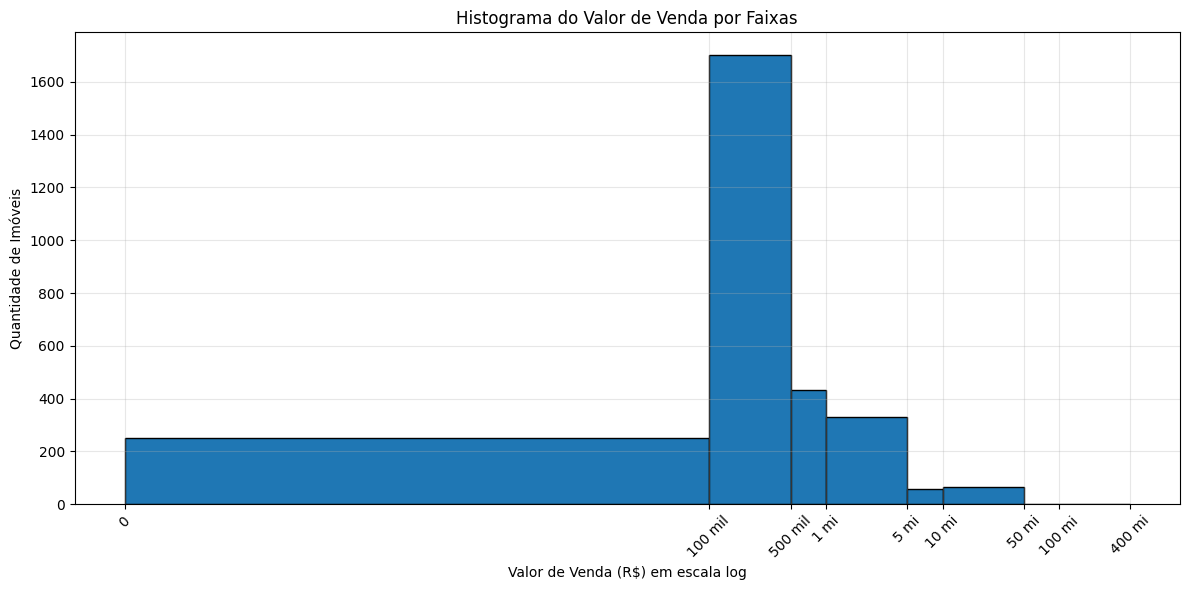



O gráfico mostra que a maioria dos imóveis são vendidos entre as faixas de 100 e 500 mil.

## 4. Discussão Preliminar
Na discussão, destaque:  
- Questões de qualidade dos dados:
  - Entendimento junto a área de negócio, para entendimento mais claro sobre os três campos dedicados a ÁREA DO IMÓVEL. O entendimento e o porquê dessa informação ser relevante, pois as 3 medidas são divulgadas no edital de licitação, então o cliente tem ciência da capacidade de construção do imóvel. 
    Entao temos:
      - Área (m2): área do imóvel/lote, registrada em cartório
      - Área Base (m2): área de construção básica do imóvel/lote (sem incidência de ODIR - Outorga Onerosa de Direito de Construir)
      - Área Máxima de Construção (m2): área de máxima de construção do imóvel/lote, cuja diferença entre ela e a area básica, haverá incidência de ODIR.
  - Alguns registros, não possuem a informação de ÁREA MAXIMA CONTRUÍDA (area_max_constr), então padronizaremos esse campo, com o valor da área base (campo imediatamente igual ou inferior).
  - Em caso do imóvel, por algum motivo, não tiver a informação da vistoria na base de dados, o sistema preencherá o campo situacao_vistoria com o valor  "SEM VISTORIA"
  - Identificado vendas de imóveis agrupados, ou seja, um item de edital é composto de mais de um imóvel e são vendidos em conjunto. Esses itens poderão interferir  na modelagem, pois os vários imóveis agrupados em um item de edital, trazem o mesmo valor de venda, que na verdade é o valor de venda do item como um todo (todos os imóveis). Sendo assim, ao identificar estes itens agrupados, optaremos por removê-los da análise, que resultará da retirada de 157 imóveis.
- Também verificamos que alguns imóveis possuem o valor de venda, muito superiores ao valor da avaliação (Ágio absoluto). Procuramos verificar se possuem correlação com o número de propostas (imóvel concorrido), ou se pode estar correlacionado com a situação da vistoria (ou seja, o ocupante faz um lance alto para garantir sua permanência no imóvel).
- Decidir se a variável QTD_OFERTAS entrará no modelo. É uma variável que negocialmente tem importância, pois mostra a concorrência de um determinado imóvel, porém, é uma variável, que a depender do momento que o modelo for testado, poderá ser considerada uma variável futura, então discutiremos sobre a retirada da mesma.
---

## 5. Próximos Passos
- Fazendo os ajustes identificados no passo anterior, nossa base estará preparada para os treinos e testes.
- A variável alvo, é o VALOR FINAL DA VENDA (valor_venda)
- Os valores derivados do VALOR FINAL DA VENDA (AGIO_ABSOLUTO e AGIO_PERCENTUAL), que foram calculados antes, para fins de análise, serão retirados para evitar vazamento de dados.
- Como o valor do laudo, é uma variável indicadora forte, porém, ela é definida ANTES da venda, faremos testes de regressao logística com RandomForestRegression e KNeighborsRegressor, tanto com a variável inclusa no modelo, e também faremos testes de regressão sem a variável VALOR_LAUDO no modelo, para verificarmos e se o modelo consegue predizer o valor da venda, mesmo sem possuir o valor do laudo.

- Fontes de dados  (bases de dados da Terracap)
- Site da Terracap que possui informações de licitações (https://www.terracap.df.gov.br)  
- Exemplo de um edital, link direto. Informações dos itens a partir da página 5 (https://www.terracap.df.gov.br/uploads/edicts/69a0c2ddeafb1.pdf)
- Exemplo de publicação de dados dos vencedores da Licitação 02/2026 - página 77 (AVISO DE HOMOLOGAÇÃO E CONVOCAÇÃO DE LICITAÇÃO
REFERENTE AO EDITAL Nº 02/2026–IMÓVEIS) (https://dodf.df.gov.br/dodf/jornal/visualizar-pdf?pasta=2026|02_Fevereiro|DODF%20038%2027-02-2026|&arquivo=DODF%20038%2027-02-2026%20INTEGRA.pdf)